In [1]:

import wrds
import pandas as pd
db = wrds.Connection(wrds_username='你的用户名')

print(db.list_libraries())

print(db.list_tables('comp'))
db.close()

/Users/au/anaconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Enter your WRDS username [你的用户名]:jinzichun
Enter your password:········
WRDS recommends setting up a .pgpass file.
Create .pgpass file now [y/n]?: y
Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done
['aha_sample', 'ahasamp', 'auditsmp', 'auditsmp_all', 'bank', 'bank_all', 'bank_premium_samp', 'banksamp', 'block', 'block_all', 'boardex_trial', 'boardsmp', 'bvd', 'bvd_amadeus_trial', 'bvd_bvdbankf', 'bvd_bvdbankf_trial', 'bvd_orbis_trial', 'bvdsamp', 'calcbench_trial', 'calcbnch', 'candid_samp', 'cboe', 'cboe_all', 'cboe_sample', 'cboesamp', 'cddsamp', 'ciq', 'ciq_capstrct', 'ciq_common', 'ciqsamp', 'ciqsamp_capstrct', 'ciqsamp_common', 'ciqsamp_keydev', 'ciqsamp_pplintel', 'ciqsamp_ratings', 'ciqsamp_transactions', 'ciqsamp_transcripts', 'cisdmsmp', 'columnar', 'comp', 'comp_execucomp', 'comp_global_daily', 'comp_na_daily_all', 'comp_urq', 'comph', 'compsamp', 'compsamp_all', 'compsamp_co

In [6]:

tickers = "('WMT', 'TGT')"
start_year = 2020
end_year = 2025

sql_query = f"""
SELECT 
    tic,
    fyear,
    sale,
    cogs,
    ni,
    at,
    invt,
    teq
FROM comp.funda
WHERE tic IN {tickers}
    AND fyear BETWEEN {start_year} AND {end_year}
    AND indfmt = 'INDL'
    AND datafmt = 'STD'
    AND popsrc = 'D'
    AND consol = 'C'
ORDER BY tic, fyear
"""

data = db.raw_sql(sql_query)

print("First 5 rows of data:")
print(data.head())

print("\nData shape (rows, columns):")
print(data.shape)

print("\nYear distribution by company:")
print(data.groupby('tic')['fyear'].value_counts().sort_index())

# Save data to CSV file
data.to_csv('wmt_tgt_raw.csv', index=False)
print("\nData successfully saved to wmt_tgt_raw.csv")

First 5 rows of data:
   tic  fyear      sale     cogs      ni       at     invt      teq
0  TGT   2020   93561.0  65696.0  4368.0  51248.0  10653.0  14440.0
1  TGT   2021  106005.0  74665.0  6946.0  53811.0  13902.0  12827.0
2  TGT   2022  109120.0  81914.0  2780.0  53335.0  13499.0  11232.0
3  TGT   2023  107412.0  77350.0  4138.0  55356.0  11886.0  13432.0
4  TGT   2024  106566.0  76050.0  4091.0  57769.0  12740.0  14666.0

Data shape (rows, columns):
(12, 8)

Year distribution by company:
tic  fyear
TGT  2020     1
     2021     1
     2022     1
     2023     1
     2024     1
     2025     1
WMT  2020     1
     2021     1
     2022     1
     2023     1
     2024     1
     2025     1
Name: count, dtype: Int64

Data successfully saved to wmt_tgt_raw.csv


In [7]:
df = data.copy()

df['gross_margin'] = (df['sale'] - df['cogs']) / df['sale']
df['net_margin'] = df['ni'] / df['sale']
df['roa'] = df['ni'] / df['at']
df['roe'] = df['ni'] / df['teq']
df['inventory_turnover'] = df['cogs'] / df['invt']

print("===== Calculation completed! Financial ratios for both companies =====\n")
print(df[['tic', 'fyear', 'gross_margin', 'net_margin', 'roa', 'roe', 'inventory_turnover']])

df.to_csv('wmt_tgt_ratios.csv', index=False)
print("\nRatios successfully saved to wmt_tgt_ratios.csv")

===== Calculation completed! Financial ratios for both companies =====

    tic  fyear  gross_margin  net_margin       roa       roe  \
0   TGT   2020      0.297827    0.046686  0.085233  0.302493   
1   TGT   2021      0.295646    0.065525  0.129081  0.541514   
2   TGT   2022      0.249322    0.025477  0.052123  0.247507   
3   TGT   2023      0.279876    0.038525  0.074753   0.30807   
4   TGT   2024      0.286358    0.038389  0.070817  0.278944   
5   TGT   2025      0.284272     0.03536  0.062279  0.229199   
6   WMT   2020      0.265328    0.024258  0.053506  0.154345   
7   WMT   2021      0.266018    0.023989   0.05584  0.148796   
8   WMT   2022      0.255891    0.019195  0.048027  0.139456   
9   WMT   2023      0.259313    0.024021  0.061454  0.171679   
10  WMT   2024      0.264703    0.028652  0.074518  0.199505   
11  WMT   2025      0.266879      0.0308  0.076907  0.206758   

    inventory_turnover  
0             6.166901  
1              5.37081  
2             6.0681

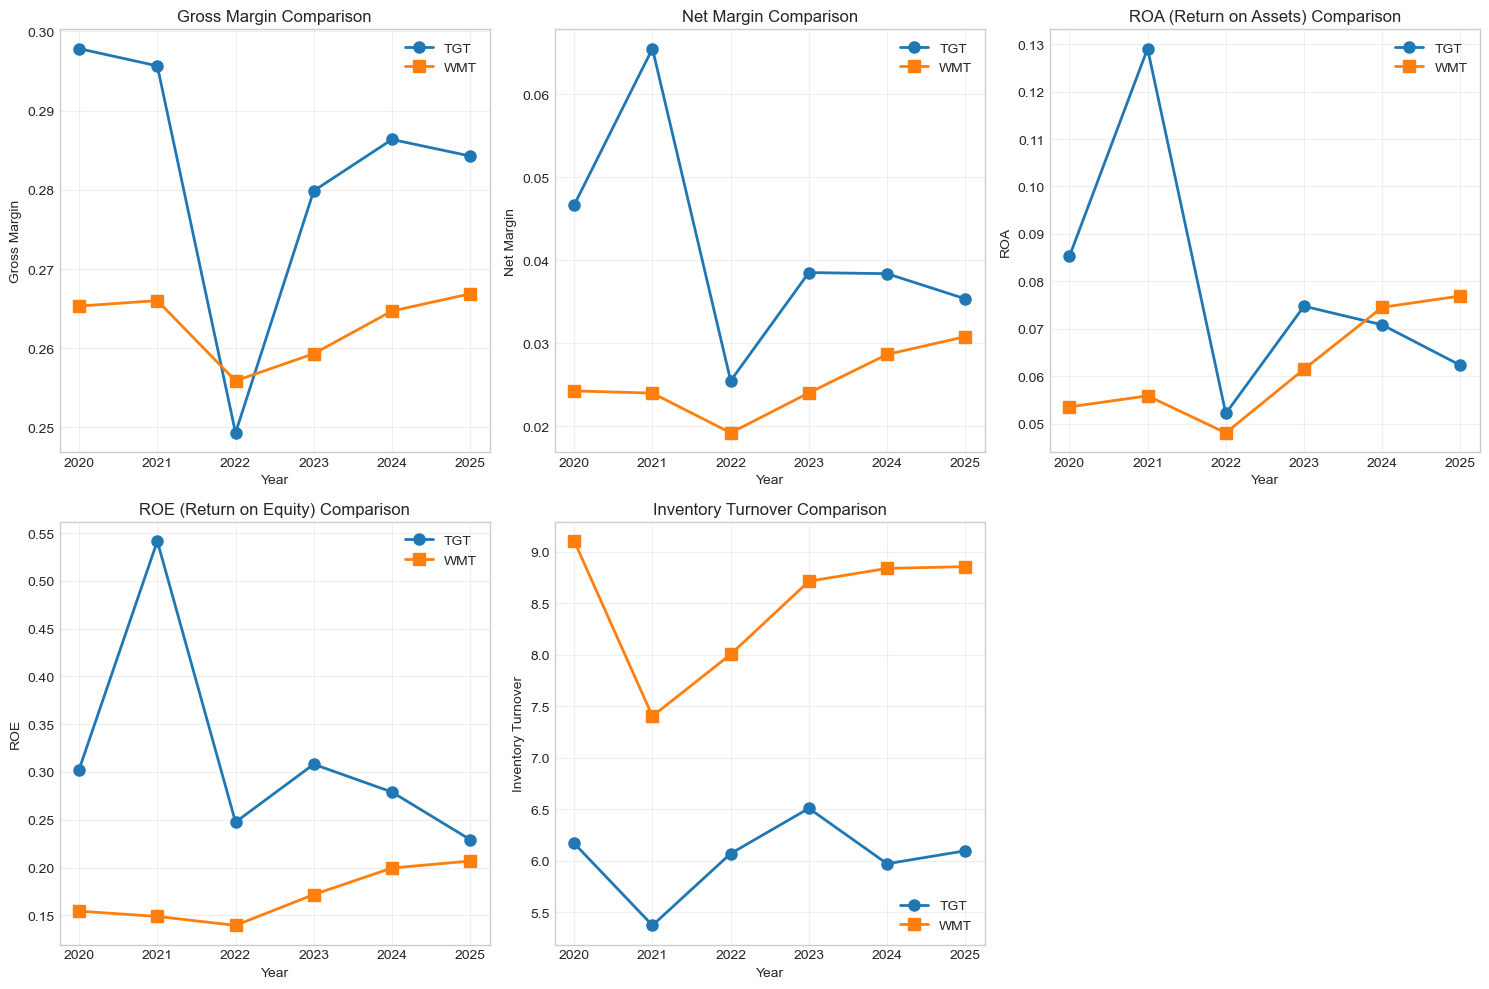

Chart saved as wmt_tgt_comparison.png


In [8]:
import matplotlib.pyplot as plt

# Extract data for both companies
tgt = df[df['tic'] == 'TGT'].copy()
wmt = df[df['tic'] == 'WMT'].copy()

plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Chart 1: Gross Margin
axes[0, 0].plot(tgt['fyear'], tgt['gross_margin'], 'o-', linewidth=2, markersize=8, label='TGT')
axes[0, 0].plot(wmt['fyear'], wmt['gross_margin'], 's-', linewidth=2, markersize=8, label='WMT')
axes[0, 0].set_title('Gross Margin Comparison', fontsize=12)
axes[0, 0].set_xlabel('Year')
axes[0, 0].set_ylabel('Gross Margin')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Chart 2: Net Margin
axes[0, 1].plot(tgt['fyear'], tgt['net_margin'], 'o-', linewidth=2, markersize=8, label='TGT')
axes[0, 1].plot(wmt['fyear'], wmt['net_margin'], 's-', linewidth=2, markersize=8, label='WMT')
axes[0, 1].set_title('Net Margin Comparison', fontsize=12)
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_ylabel('Net Margin')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Chart 3: Return on Assets (ROA)
axes[0, 2].plot(tgt['fyear'], tgt['roa'], 'o-', linewidth=2, markersize=8, label='TGT')
axes[0, 2].plot(wmt['fyear'], wmt['roa'], 's-', linewidth=2, markersize=8, label='WMT')
axes[0, 2].set_title('ROA (Return on Assets) Comparison', fontsize=12)
axes[0, 2].set_xlabel('Year')
axes[0, 2].set_ylabel('ROA')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# Chart 4: Return on Equity (ROE)
axes[1, 0].plot(tgt['fyear'], tgt['roe'], 'o-', linewidth=2, markersize=8, label='TGT')
axes[1, 0].plot(wmt['fyear'], wmt['roe'], 's-', linewidth=2, markersize=8, label='WMT')
axes[1, 0].set_title('ROE (Return on Equity) Comparison', fontsize=12)
axes[1, 0].set_xlabel('Year')
axes[1, 0].set_ylabel('ROE')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Chart 5: Inventory Turnover
axes[1, 1].plot(tgt['fyear'], tgt['inventory_turnover'], 'o-', linewidth=2, markersize=8, label='TGT')
axes[1, 1].plot(wmt['fyear'], wmt['inventory_turnover'], 's-', linewidth=2, markersize=8, label='WMT')
axes[1, 1].set_title('Inventory Turnover Comparison', fontsize=12)
axes[1, 1].set_xlabel('Year')
axes[1, 1].set_ylabel('Inventory Turnover')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# Hide the 6th subplot (not used)
axes[1, 2].axis('off')

plt.tight_layout()
plt.savefig('wmt_tgt_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved as wmt_tgt_comparison.png")

In [1]:
import wrds
import pandas as pd

db = wrds.Connection(wrds_username='jinzichun')

/Users/au/anaconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Loading library list...
Done


In [9]:
# Extract monthly stock price data

# Define tickers and date range
ticker_list = "('WMT', 'TGT')"
start_date_stock = "2020-01-01"
end_date_stock = "2025-12-31"

# SQL query: join to get monthly stock prices via permno
sql_stock = f"""
SELECT 
    a.permno,
    a.date,
    a.ret,
    a.prc,
    b.htsymbol as ticker
FROM crsp.msf a
LEFT JOIN crsp.msfhdr b ON a.permno = b.permno
WHERE b.htsymbol IN {ticker_list}
    AND a.date BETWEEN '{start_date_stock}' AND '{end_date_stock}'
ORDER BY b.htsymbol, a.date
"""

stock_data = db.raw_sql(sql_stock)

print("First 5 rows of stock data:")
print(stock_data.head())

print(f"\nData shape: {stock_data.shape}")
print(f"Date range: {stock_data['date'].min()} to {stock_data['date'].max()}")

First 5 rows of stock data:
   permno        date       ret     prc ticker
0   49154  2020-01-31 -0.136261  110.74    TGT
1   49154  2020-02-28 -0.063934   103.0    TGT
2   49154  2020-03-31 -0.097379   92.97    TGT
3   49154  2020-04-30  0.180381  109.74    TGT
4   49154  2020-05-29   0.12074  122.33    TGT

Data shape: (120, 5)
Date range: 2020-01-31 to 2024-12-31


In [10]:
# Clean stock data
# Drop rows with missing returns
stock_clean = stock_data.dropna(subset=['ret']).copy()

# Convert date to datetime format
stock_clean['date'] = pd.to_datetime(stock_clean['date'])

# Sort by ticker and date
stock_clean = stock_clean.sort_values(['ticker', 'date'])

# Calculate cumulative return
stock_clean['cumulative_return'] = stock_clean.groupby('ticker')['ret'].transform(
    lambda x: (1 + x).cumprod() - 1
)

# Check data count per company
print("Monthly data count per company:")
print(stock_clean['ticker'].value_counts())

# Summary statistics of cumulative returns
print("\nCumulative return statistics:")
print(stock_clean.groupby('ticker')['cumulative_return'].describe())

Monthly data count per company:
ticker
TGT    60
WMT    60
Name: count, dtype: Int64

Cumulative return statistics:
        count      mean       std       min       25%       50%       75%  \
ticker                                                                      
TGT      60.0  0.358233  0.326262 -0.270216   0.15922  0.317653  0.479167   
WMT      60.0  0.365561  0.345609 -0.093908  0.180692  0.256252  0.424199   

             max  
ticker            
TGT     1.091268  
WMT     1.510625  


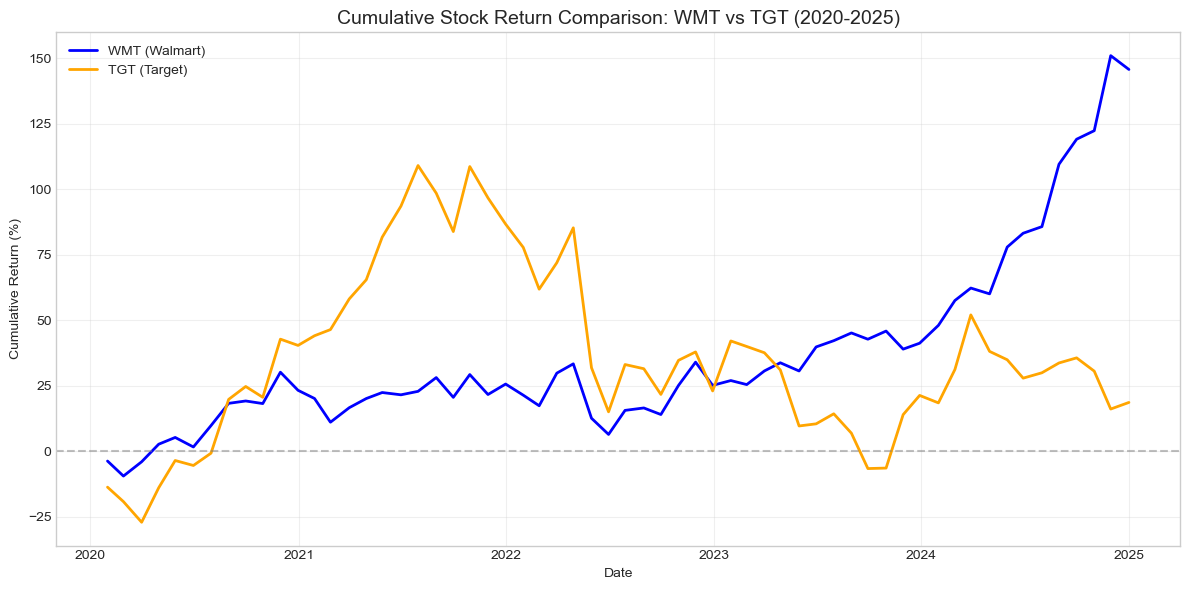

Stock return chart saved as stock_returns_comparison.png


In [11]:
# Plot cumulative stock returns comparison
import matplotlib.pyplot as plt

# Extract data for both companies
wmt_stock = stock_clean[stock_clean['ticker'] == 'WMT'].copy()
tgt_stock = stock_clean[stock_clean['ticker'] == 'TGT'].copy()

# Create chart
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(wmt_stock['date'], wmt_stock['cumulative_return'] * 100, 
        'b-', linewidth=2, label='WMT (Walmart)')
ax.plot(tgt_stock['date'], tgt_stock['cumulative_return'] * 100, 
        'orange', linewidth=2, label='TGT (Target)')

ax.set_title('Cumulative Stock Return Comparison: WMT vs TGT (2020-2025)', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Return (%)')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

# Add zero line
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('stock_returns_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("Stock return chart saved as stock_returns_comparison.png")

In [12]:
# Calculate annual stock returns from monthly data
stock_clean['year'] = stock_clean['date'].dt.year

annual_stock_return = stock_clean.groupby(['ticker', 'year'])['ret'].apply(
    lambda x: (1 + x).prod() - 1
).reset_index()
annual_stock_return.columns = ['tic', 'fyear', 'annual_return']

print("Annual stock returns calculated:")
print(annual_stock_return)

Annual stock returns calculated:
   tic  fyear  annual_return
0  TGT   2020       0.404745
1  TGT   2021       0.329555
2  TGT   2022      -0.340920
3  TGT   2023      -0.013892
4  TGT   2024      -0.022046
5  WMT   2020       0.233410
6  WMT   2021       0.019332
7  WMT   2022      -0.003983
8  WMT   2023       0.128481
9  WMT   2024       0.739324


In [13]:
# Merge with financial ratios
df_merged = df.merge(annual_stock_return, on=['tic', 'fyear'], how='inner')

print(f"Merged data shape: {df_merged.shape}")
print(df_merged[['tic', 'fyear', 'roa', 'roe', 'net_margin', 'annual_return']])

Merged data shape: (10, 14)
   tic  fyear       roa       roe  net_margin  annual_return
0  TGT   2020  0.085233  0.302493    0.046686       0.404745
1  TGT   2021  0.129081  0.541514    0.065525       0.329555
2  TGT   2022  0.052123  0.247507    0.025477      -0.340920
3  TGT   2023  0.074753   0.30807    0.038525      -0.013892
4  TGT   2024  0.070817  0.278944    0.038389      -0.022046
5  WMT   2020  0.053506  0.154345    0.024258       0.233410
6  WMT   2021   0.05584  0.148796    0.023989       0.019332
7  WMT   2022  0.048027  0.139456    0.019195      -0.003983
8  WMT   2023  0.061454  0.171679    0.024021       0.128481
9  WMT   2024  0.074518  0.199505    0.028652       0.739324


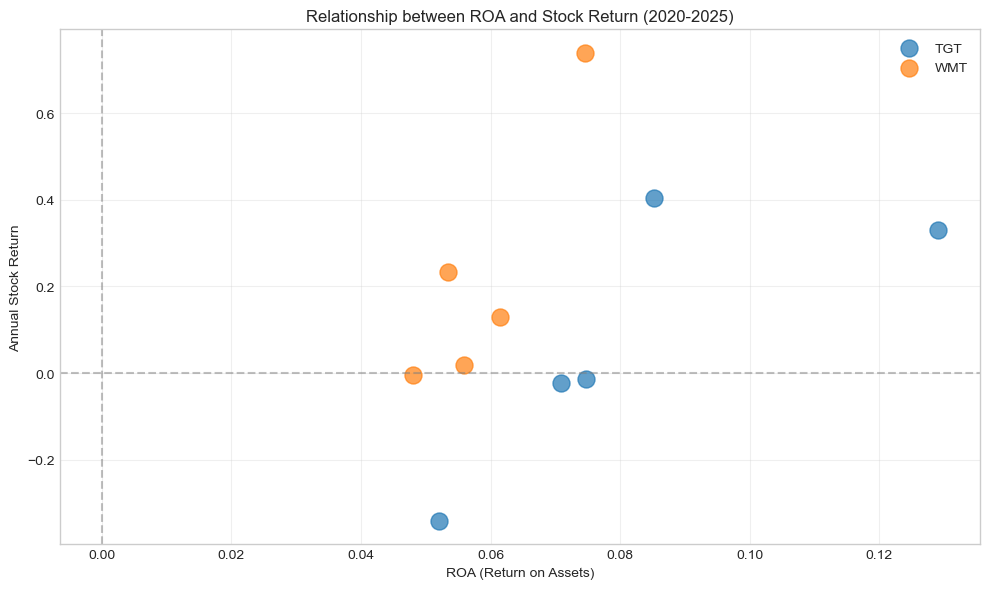

Scatter plot saved as correlation_roa_vs_return.png


In [14]:
# Scatter plot
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

for tic in df_merged['tic'].unique():
    subset = df_merged[df_merged['tic'] == tic]
    ax.scatter(subset['roa'], subset['annual_return'], label=tic, s=150, alpha=0.7)

ax.set_xlabel('ROA (Return on Assets)')
ax.set_ylabel('Annual Stock Return')
ax.set_title('Relationship between ROA and Stock Return (2020-2025)')
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('correlation_roa_vs_return.png', dpi=150)
plt.show()

print("Scatter plot saved as correlation_roa_vs_return.png")